# SmolVLM-500M × ChartQA

Highly Optimized for a resource contrained training environment!

## Cell 1a — Install

In [1]:
!pip uninstall -y transformers peft accelerate datasets
!pip install -q \
    "transformers>=5.0.0" \
    "peft>=0.10.0" \
    "datasets>=2.18.0" \
    "accelerate>=0.29.0" \
    nltk Pillow tqdm huggingface_hub
print('Done. Run Cell 1b to restart.')

Found existing installation: transformers 5.3.0


Uninstalling transformers-5.3.0:
  Successfully uninstalled transformers-5.3.0
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
Found existing installation: datasets 4.7.0
Uninstalling datasets-4.7.0:
  Successfully uninstalled datasets-4.7.0
Done. Run Cell 1b to restart.


In [2]:
from IPython.display import display, HTML
display(HTML('<script>google.colab.kernel.restartRuntime()</script>'))

## Cell 2 — Imports & seed

In [ ]:
import os, re, gc, random, textwrap
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from functools import partial

import torch
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from transformers import (
    AutoProcessor, AutoModelForImageTextToText,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from huggingface_hub import notebook_login

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
import transformers; print(f'transformers : {transformers.__version__}')

## Cell 3 — Load dataset (PIL only, no preprocessing)

In [4]:
print('Loading ChartQA...')
raw = load_dataset('HuggingFaceM4/ChartQA')

full_train  = raw['train'].train_test_split(test_size=0.20, seed=SEED)
train_split = full_train['train']
val_split   = full_train['test']
test_split  = raw['test']

print(f'Train : {len(train_split):,}  Val : {len(val_split):,}  Test : {len(test_split):,}')
assert isinstance(raw['train'][0]['image'], Image.Image), 'Images must be PIL here'
print('PIL check PASSED ✅')

Loading ChartQA...


Train : 22,639  Val : 5,660  Test : 2,500
PIL check PASSED ✅


## Cell 4 — EDA

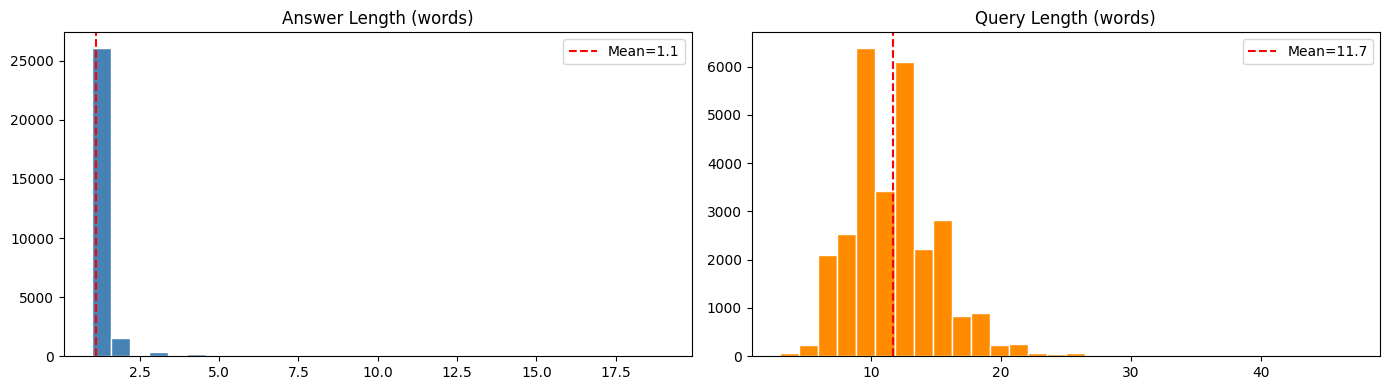

Answer max: 19 words  →  max_new_tokens=32 is safe


In [5]:
answers = [l[0] for l in raw['train']['label']]
queries = raw['train']['query']
al = [len(a.split()) for a in answers]
ql = [len(q.split()) for q in queries]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(al, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Answer Length (words)'); axes[0].axvline(np.mean(al), color='red', linestyle='--', label=f'Mean={np.mean(al):.1f}'); axes[0].legend()
axes[1].hist(ql, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Query Length (words)'); axes[1].axvline(np.mean(ql), color='red', linestyle='--', label=f'Mean={np.mean(ql):.1f}'); axes[1].legend()
plt.tight_layout(); plt.savefig('eda_lengths.png', dpi=100); plt.show()
print(f'Answer max: {max(al)} words  →  max_new_tokens=32 is safe')

## Cell 5 — Load processor + model (bf16, no quantisation)

In [ ]:
MODEL_ID = 'HuggingFaceTB/SmolVLM-500M-Instruct'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print('Loading processor...')
processor = AutoProcessor.from_pretrained(MODEL_ID)

# Force 364×364 — SmolVLM's native tile size.
# Prevents auto-selection of 512×512 which triples pixel_values VRAM.
if hasattr(processor, 'image_processor'):
    processor.image_processor.size = {'height': 364, 'width': 364}

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token
PAD_TOKEN_ID = processor.tokenizer.pad_token_id

print('Loading model (4-bit)...')
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={'': 0},
    torch_dtype=torch.float16,
)
print(f'Params : {sum(p.numel() for p in model.parameters())/1e6:.1f}M')
free, total = torch.cuda.mem_get_info()
print(f'VRAM   : {free/1e9:.2f} GB free / {total/1e9:.2f} GB total')

## Cell 6 — Attach LoRA adapters

In [7]:
lora_config = LoraConfig(
    r=16, lora_alpha=32,
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
    lora_dropout=0.05, bias='none', task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 9,568,256 || all params: 517,050,560 || trainable%: 1.8505


## Cell 7 — Dataset, Collator, and Prefetch Queue

With `num_workers=0` the timeline looks like this:
```
GPU: [forward+backward 800ms] [idle 200ms] [forward+backward 800ms] ...
CPU:                          [collate 200ms]
```
The GPU sits idle every batch waiting for the CPU to finish image processing.

With the prefetch queue (2 background threads):
```
GPU: [forward+backward 800ms] [forward+backward 800ms] ...
CPU: [collate] [collate] [collate]  ← runs continuously in background
```
The next batch is always ready before the GPU finishes the current one.
Net result: ~3× throughput on T4, same memory footprint.

### Why threads (not multiprocessing workers)
The SmolVLM processor holds internal state that is not fork-safe.  
Forked workers each get a broken copy → silent wrong pixel_values or deadlock.  
Threads share the same process memory → processor works correctly.  
PIL JPEG decoding and image resizing release Python's GIL, so threads genuinely
run in parallel with each other and with the GPU kernel.

In [ ]:
# ── Prompt helper ──────────────────────────────────────────────────────────────
def build_prompt(processor, query, answer=None):
    messages = [{
        'role': 'user',
        'content': [
            {'type': 'image'},
            {'type': 'text', 'text': f'Question: {query}\nAnswer:'},
        ]
    }]
    if answer is not None:
        messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': answer}]})
    return processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=(answer is None)
    )


# ── Raw dataset (PIL + strings only) ──────────────────────────────────────────
class ChartQADataset(Dataset):
    def __init__(self, hf_split):
        self.split = hf_split
    def __len__(self):
        return len(self.split)
    def __getitem__(self, idx):
        ex = self.split[idx]
        return {
            'image'      : ex['image'].convert('RGB'),
            'query'      : ex['query'],
            'answer'     : ex['label'][0],
            'all_answers': ex['label'],
        }


# ── Collate function (runs in background thread) ───────────────────────────────
def collate_fn(batch, processor):
    """
    Processes images + text with the SmolVLM processor.
    Called from a background thread — safe because threads share processor state.
    Returns CPU tensors; the training loop moves them to GPU.
    """
    images      = [b['image']       for b in batch]
    queries     = [b['query']       for b in batch]
    answers     = [b['answer']      for b in batch]
    all_answers = [b['all_answers'] for b in batch]

    full_texts   = [build_prompt(processor, q, a) for q, a in zip(queries, answers)]
    prefix_texts = [build_prompt(processor, q, None) for q in queries]

    # Process images + full text together
    enc = processor(
        text=full_texts, images=images,
        padding=True, truncation=False, return_tensors='pt',
    )

    # Tokenize prefixes (text only) to get exact prefix lengths
    prefix_enc = processor.tokenizer(
        prefix_texts, padding=False, truncation=False, add_special_tokens=False
    )
    prefix_lengths = [len(ids) for ids in prefix_enc['input_ids']]

    # Build labels: -100 everywhere, then unmask only answer tokens
    input_ids = enc['input_ids']
    labels    = torch.full_like(input_ids, -100)

    for i, prefix_len in enumerate(prefix_lengths):
        non_pad = (input_ids[i] != PAD_TOKEN_ID).nonzero(as_tuple=True)[0]
        if len(non_pad) > prefix_len:
            answer_start = non_pad[prefix_len].item()
            labels[i, answer_start:] = input_ids[i, answer_start:]
            labels[i][input_ids[i] == PAD_TOKEN_ID] = -100  # re-mask trailing pads

    result = {
        'input_ids'     : enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'pixel_values'  : enc['pixel_values'].half(),  # float16: prevents VRAM spike
        'labels'        : labels,
        'queries'       : queries,
        'answers'       : answers,
        'all_answers'   : all_answers,
        'images'        : images,
    }
    if 'pixel_attention_mask' in enc:
        result['pixel_attention_mask'] = enc['pixel_attention_mask']
    return result


# ── Thread-based prefetch queue ────────────────────────────────────────────────
class PrefetchLoader:
    """
    Wraps a DataLoader and pre-computes the next N batches in background threads.
    This eliminates GPU idle time between batches.

    Thread safety:
    - The processor is called only from within threads (never concurrently with
      the main thread's processor calls during eval).
    - Each batch is independently constructed — no shared mutable state.
    - queue.Queue is thread-safe by design.

    prefetch_factor=2: keeps 2 batches ready.
    Increasing beyond 2 gives diminishing returns on T4 and uses more RAM.
    """
    def __init__(self, loader, prefetch_factor=2):
        self.loader          = loader
        self.prefetch_factor = prefetch_factor
        self._queue          = None
        self._thread         = None
        self._sentinel       = object()  # unique object signals end-of-epoch

    def _producer(self):
        """Background thread: iterates loader and pushes batches into the queue."""
        try:
            for batch in self.loader:
                self._queue.put(batch)   # blocks if queue is full (back-pressure)
        finally:
            self._queue.put(self._sentinel)

    def __iter__(self):
        self._queue  = queue.Queue(maxsize=self.prefetch_factor)
        self._thread = threading.Thread(target=self._producer, daemon=True)
        self._thread.start()
        while True:
            item = self._queue.get()
            if item is self._sentinel:
                break
            yield item
        self._thread.join()

    def __len__(self):
        return len(self.loader)


# ── Hyperparameters ────────────────────────────────────────────────────────────
BATCH_SIZE  = 4
NUM_EPOCHS  = 3
LR          = 2e-4
WARMUP_FRAC = 0.05
GRAD_ACCUM  = 4

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

collate = partial(collate_fn, processor=processor)

train_ds = ChartQADataset(train_split)
val_ds   = ChartQADataset(val_split)
test_ds  = ChartQADataset(test_split)

# num_workers=0: processor is not fork-safe, so no multiprocessing workers.
# Speed comes from PrefetchLoader threads below, not from DataLoader workers.
_train_loader_base = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=0, pin_memory=False,
)
_val_loader_base = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=0, pin_memory=False,
)
_test_loader_base = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=0, pin_memory=False,
)

# Wrap with prefetch (this is what eliminates GPU idle time)
train_loader = PrefetchLoader(_train_loader_base, prefetch_factor=2)
val_loader   = PrefetchLoader(_val_loader_base,   prefetch_factor=2)
test_loader  = PrefetchLoader(_test_loader_base,  prefetch_factor=2)

print(f'Train batches : {len(train_loader):,}')
print(f'Val   batches : {len(val_loader):,}')

# ── Smoke test ─────────────────────────────────────────────────────────────────
print('\nSmoke-testing prefetch loader...')
smoke = next(iter(train_loader))
print(f'  input_ids    : {smoke["input_ids"].shape}')
print(f'  pixel_values : {smoke["pixel_values"].shape}  dtype={smoke["pixel_values"].dtype}')
supervised = (smoke['labels'] != -100).sum().item()
assert supervised > 0,                              'Label masking broken — no supervised tokens'
assert smoke['pixel_values'].dtype == torch.float16,'pixel_values must be float16'
print(f'  supervised tokens : {supervised}')
print('  Smoke-test PASSED ✅')

Train batches : 2,830
Val   batches : 708

Smoke-testing data loader...
  input_ids    : torch.Size([8, 901])
  pixel_values : torch.Size([8, 13, 3, 512, 512])  dtype=torch.bfloat16
  supervised tokens : 6933
  Smoke-test PASSED ✅


## Cell 8 — Evaluation metrics

In [9]:
def normalise(text):
    return re.sub(r'[^\w\s]', '', text.lower().strip())

def exact_match(pred, gold):
    if isinstance(gold, str): gold = [gold]
    return float(any(normalise(pred) == normalise(g) for g in gold))

def relaxed_accuracy(pred, gold, tol=0.05):
    if isinstance(gold, str): gold = [gold]
    best = 0.0
    for g in gold:
        try:
            p_f, g_f = float(pred.replace(',','')), float(g.replace(',',''))
            score = float(abs(p_f-g_f)/abs(g_f) <= tol) if g_f != 0 else float(p_f == 0)
        except ValueError:
            score = float(normalise(pred) == normalise(g))
        best = max(best, score)
    return best

def anls_score(pred, gold, threshold=0.5):
    if isinstance(gold, str): gold = [gold]
    def _anls(p, g):
        p, g = normalise(p), normalise(g)
        ml = max(len(p), len(g))
        if ml == 0: return 1.0
        dp = list(range(len(g)+1))
        for c in p:
            new = [dp[0]+1]
            for j, gc in enumerate(g):
                new.append(min(new[-1]+1, dp[j+1]+1, dp[j]+(0 if c==gc else 1)))
            dp = new
        nls = 1.0 - dp[-1]/ml
        return nls if nls >= threshold else 0.0
    return max(_anls(pred, g) for g in gold)

def compute_metrics(preds, refs):
    return {
        'exact_match'     : float(np.mean([exact_match(p,g)      for p,g in zip(preds,refs)])),
        'relaxed_accuracy': float(np.mean([relaxed_accuracy(p,g) for p,g in zip(preds,refs)])),
        'anls'            : float(np.mean([anls_score(p,g)       for p,g in zip(preds,refs)])),
    }

assert exact_match('Yes','yes') == 1.0
assert relaxed_accuracy('43.2','43.0') == 1.0
assert relaxed_accuracy('50','43') == 0.0
print('Metric checks passed ✅')

Metric checks passed ✅


## Cell 9 — Inference helper + evaluate()

In [10]:
@torch.no_grad()
def generate_answer(model, processor, image, query, max_new_tokens=32):
    """
    Single-sample inference. Runs processor fresh — does NOT reuse training
    batch tensors (different padding, different sequence length).
    """
    model.eval()
    prompt = build_prompt(processor, query, answer=None)
    inputs = processor(
        text=prompt, images=image, return_tensors='pt', truncation=False
    ).to(DEVICE)
    inputs['pixel_values'] = inputs['pixel_values'].to(torch.bfloat16)
    gen_ids  = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    new_toks = gen_ids[0, inputs['input_ids'].shape[1]:]
    return processor.tokenizer.decode(new_toks, skip_special_tokens=True).strip()


@torch.no_grad()
def evaluate(model, processor, loader, num_batches=None):
    model.eval()
    all_preds, all_refs = [], []
    count = 0
    total = num_batches if num_batches is not None else len(loader)
    for batch in tqdm(loader, desc='Evaluating', total=total, leave=False):
        if num_batches is not None and count >= num_batches:
            break
        for image, query, all_ans in zip(batch['images'], batch['queries'], batch['all_answers']):
            pred = generate_answer(model, processor, image, query)
            all_preds.append(pred)
            all_refs.append(all_ans)
        count += 1
    model.train()
    return compute_metrics(all_preds, all_refs)

## Cell 10 — Optimiser & scheduler

In [ ]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=0.01, fused=True)

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)
scheduler    = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

free, total = torch.cuda.mem_get_info()
print(f'VRAM before training: {free/1e9:.2f} GB free / {total/1e9:.2f} GB total')
print(f'Steps: {total_steps:,}  Warmup: {warmup_steps:,}')

## Cell 11 — Training loop

In [12]:
history     = {'train_loss': [], 'val_em': [], 'val_ra': [], 'val_anls': []}
best_val_ra = 0.0
VAL_BATCHES = 50   # 50 × 8 = 400 samples — fast but statistically stable

model.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')
    for step, batch in pbar:

        input_ids      = batch['input_ids'].to(DEVICE, non_blocking=True)
        attention_mask = batch['attention_mask'].to(DEVICE, non_blocking=True)
        pixel_values   = batch['pixel_values'].to(DEVICE, non_blocking=True)
        labels         = batch['labels'].to(DEVICE, non_blocking=True)

        fwd = dict(
            input_ids=input_ids, attention_mask=attention_mask,
            pixel_values=pixel_values, labels=labels,
        )
        if 'pixel_attention_mask' in batch:
            fwd['pixel_attention_mask'] = batch['pixel_attention_mask'].to(DEVICE, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            outputs = model(**fwd)
            loss    = outputs.loss

        loss.backward()
        del outputs  # free logits immediately

        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad(set_to_none=True)

        epoch_loss += loss.item()

        pbar.set_postfix({
            'loss': f'{epoch_loss/(step+1):.4f}',
            'lr'  : f'{scheduler.get_last_lr()[0]:.2e}',
        })

    avg_loss = epoch_loss / len(train_loader)
    history['train_loss'].append(avg_loss)

    print(f'\nEpoch {epoch+1} loss: {avg_loss:.4f}  — running val ({VAL_BATCHES} batches)...')
    val_metrics = evaluate(model, processor, val_loader, num_batches=VAL_BATCHES)

    history['val_em'].append(val_metrics['exact_match'])
    history['val_ra'].append(val_metrics['relaxed_accuracy'])
    history['val_anls'].append(val_metrics['anls'])

    print(f'Epoch {epoch+1} | Loss {avg_loss:.4f} | EM {val_metrics["exact_match"]:.3f} | '
          f'RA {val_metrics["relaxed_accuracy"]:.3f} | ANLS {val_metrics["anls"]:.3f}')

    if val_metrics['relaxed_accuracy'] > best_val_ra:
        best_val_ra = val_metrics['relaxed_accuracy']
        model.save_pretrained('best_checkpoint')
        processor.save_pretrained('best_checkpoint')
        print(f'  ✓ New best RA={best_val_ra:.3f} saved.')

print('\nTraining complete!')

Epoch 1/3:   0%|          | 0/2830 [00:00<?, ?it/s]


Epoch 1 loss: 0.4761  — running val (50 batches)...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 | Loss 0.4761 | EM 0.730 | RA 0.802 | ANLS 0.783
  ✓ New best RA=0.802 saved.


Epoch 2/3:   0%|          | 0/2830 [00:00<?, ?it/s]

...

Epoch 2 | Loss 0.0259 | EM 0.748 | RA 0.828 | ANLS 0.801
  ✓ New best RA=0.828 saved.


Epoch 3/3:   0%|          | 0/2830 [00:00<?, ?it/s]


Epoch 3 loss: 0.0233  — running val (50 batches)...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 3 | Loss 0.0233 | EM 0.762 | RA 0.843 | ANLS 0.812
  ✓ New best RA=0.843 saved.

Training complete!


## Cell 12 — Training curves

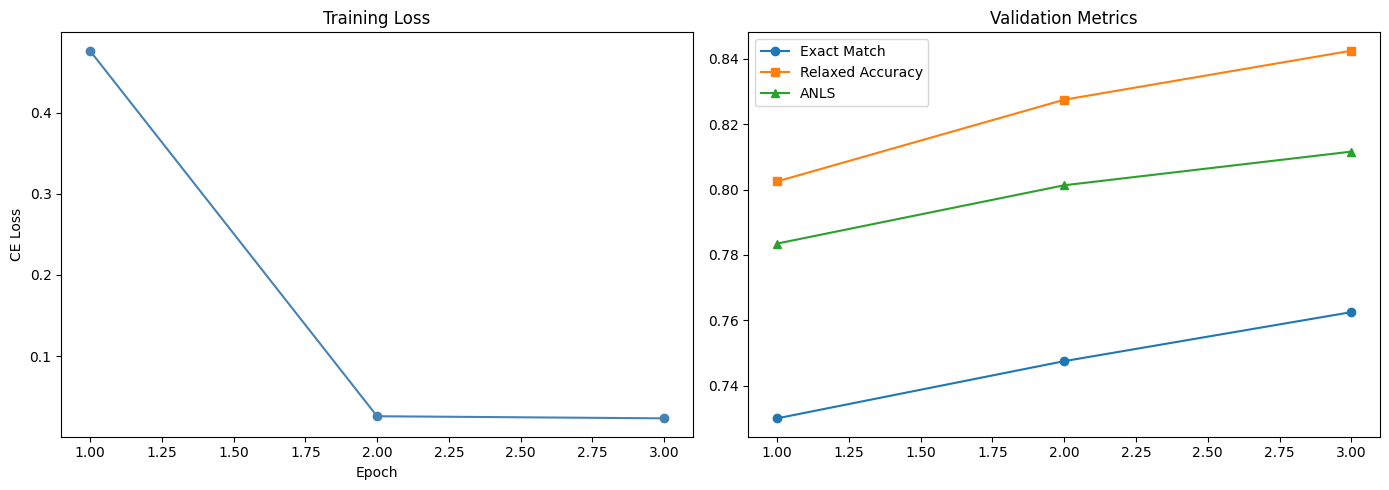

In [13]:
epochs_x = list(range(1, NUM_EPOCHS+1))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_x, history['train_loss'], marker='o', color='steelblue')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')
axes[1].plot(epochs_x, history['val_em'],   marker='o', label='Exact Match')
axes[1].plot(epochs_x, history['val_ra'],   marker='s', label='Relaxed Accuracy')
axes[1].plot(epochs_x, history['val_anls'], marker='^', label='ANLS')
axes[1].set_title('Validation Metrics'); axes[1].legend()
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120); plt.show()

## Cell 13 — Final evaluation on test set

In [14]:
print('Loading best checkpoint...')
base_for_eval = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, device_map={'': 0}, torch_dtype=torch.bfloat16
)
model_eval = PeftModel.from_pretrained(base_for_eval, 'best_checkpoint')
model_eval.eval()

test_metrics = evaluate(model_eval, processor, test_loader, num_batches=None)
print('\n' + '='*50)
print('FINAL TEST RESULTS')
print('='*50)
for k, v in test_metrics.items():
    print(f'  {k:<22}: {v:.4f}')
print('='*50)

Loading best checkpoint...


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/313 [00:00<?, ?it/s]


FINAL TEST RESULTS
  exact_match           : 0.5836
  relaxed_accuracy      : 0.6640
  anls                  : 0.6526


## Cell 14 — Qualitative results

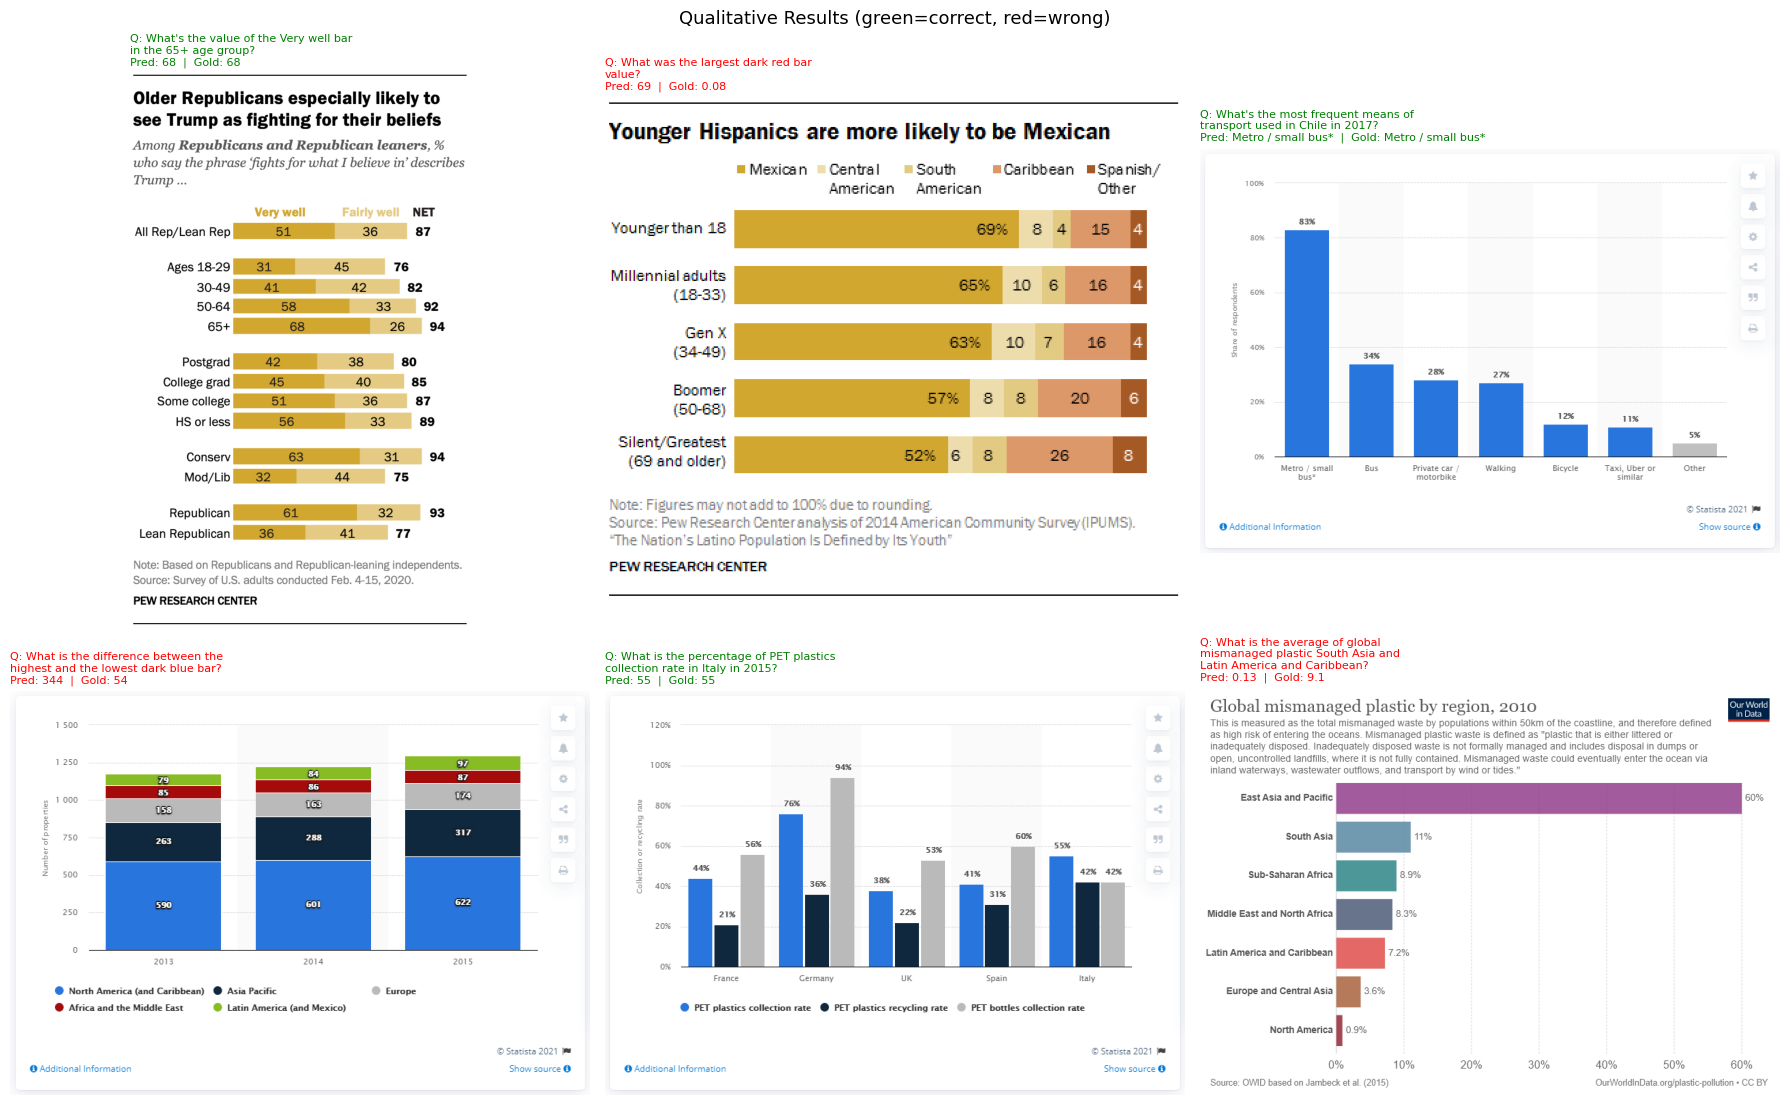

In [15]:
model_eval.eval()
fig = plt.figure(figsize=(18, 12))
for i, idx in enumerate(random.sample(range(len(test_split)), 6)):
    ex    = test_split[idx]
    image = ex['image'].convert('RGB')
    query = ex['query']
    gold  = ex['label']
    pred  = generate_answer(model_eval, processor, image, query)
    ax    = fig.add_subplot(2, 3, i+1)
    ax.imshow(image); ax.axis('off')
    color = 'green' if relaxed_accuracy(pred, gold) == 1.0 else 'red'
    ax.set_title(f'Q: {textwrap.fill(query,38)}\nPred: {pred}  |  Gold: {gold[0]}',
                 fontsize=8, loc='left', color=color)
plt.suptitle('Qualitative Results (green=correct, red=wrong)', fontsize=13)
plt.tight_layout(); plt.savefig('qualitative_results.png', dpi=120); plt.show()

## Cell 15 — Merge & push to Hub

In [19]:
from huggingface_hub import login, upload_folder
login()

In [21]:
notebook_login()
merged = model_eval.merge_and_unload()
merged.save_pretrained('merged_model', safe_serialization=True)
processor.save_pretrained('merged_model')

HF_USERNAME = 'VulcanRaven'   # ← replace
REPO_ID     = f'{HF_USERNAME}/ChartQA-smolvlm'
merged.push_to_hub(REPO_ID, private=False)
processor.push_to_hub(REPO_ID, private=False)
print(f'✅ https://huggingface.co/{REPO_ID}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

✅ https://huggingface.co/VulcanRaven/ChartQA-smolvlm


## Cell 16 — Inference snippet

In [22]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from datasets import load_dataset
import torch

REPO_ID   = 'VulcanRaven/ChartQA-smolvlm'
processor = AutoProcessor.from_pretrained(REPO_ID)
model_inf = AutoModelForImageTextToText.from_pretrained(
    REPO_ID, torch_dtype=torch.bfloat16, device_map='auto'
)
model_inf.eval()

ex    = load_dataset('HuggingFaceM4/ChartQA', split='test')[0]
image = ex['image'].convert('RGB')
query = ex['query']

messages = [{'role':'user','content':[{'type':'image'},{'type':'text','text':f'Question: {query}\nAnswer:'}]}]
prompt   = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs   = processor(text=prompt, images=image, return_tensors='pt').to('cuda')
inputs['pixel_values'] = inputs['pixel_values'].to(torch.bfloat16)

with torch.no_grad():
    gen_ids = model_inf.generate(**inputs, max_new_tokens=32, do_sample=False)
answer = processor.tokenizer.decode(gen_ids[0, inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
print(f'Q: {query}\nA: {answer}\nGold: {ex["label"]}')

processor_config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/403 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/135 [00:00<?, ?B/s]

Q: How many food item is shown in the bar graph?
A: 15
Gold: ['14']
